NOP- Experiential Learning

In [2]:
import os

# 1. Set environment variables for Kaggle
os.environ['KAGGLE_USERNAME'] = "naazfarha"
os.environ['KAGGLE_KEY'] = "0e7890f476e666aad6e6890283e85855"

# 2. Download the Chest X-Ray dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 3. Unzip with Overwrite (-o) and cleanup
if os.path.exists("chest-xray-pneumonia.zip"):
    print("Unzipping dataset...")
    # -o overwrites without asking, -q is quiet mode
    !unzip -o -q chest-xray-pneumonia.zip
    !rm chest-xray-pneumonia.zip
    # Remove hidden Mac folders if they exist
    !rm -rf chest_xray/__MACOSX
    print("Unzip complete and zip file removed.")

# 4. Verify the directories exist
print("Checking folder structure:")
!ls chest_xray

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:28<00:00, 85.3MB/s]

Unzipping dataset...
Unzip complete and zip file removed.
Checking folder structure:
chest_xray  test  train  val


$$\min_{u} \frac{1}{2} \|u - f\|_2^2 + \lambda \cdot TV(u)$$

$\frac{1}{2} \|u - f\|_2^2$: This is the Fidelity Term. It ensures the denoised image doesn't look completely different from the original.

$TV(u)$: This is the Regularization Term. For Isotropic TV, it calculates the sum of the magnitudes of the gradient at every pixel: $\sum \sqrt{(\nabla_x u)^2 + (\nabla_y u)^2}$.

$\lambda$ (Lambda): This is the hyperparameter that controls how "aggressive" the denoising is.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [14]:
class TVDenoisingLayer(nn.Module):
    def __init__(self, iterations=4, tau=0.125): # Reduced to 4 iterations for speed
        super(TVDenoisingLayer, self).__init__()
        self.iterations = iterations
        self.tau = tau
        self.lambda_tv = nn.Parameter(torch.tensor([0.05]))

    def forward(self, f):
        u = f
        batch, _, h, w = f.shape
        # Pre-allocate p to avoid creating it every forward pass
        p = torch.zeros((batch, 2, h, w), device=f.device)

        for i in range(self.iterations):
            # Faster gradient calculation using slicing instead of roll
            ux = torch.zeros_like(u)
            uy = torch.zeros_like(u)
            ux[:, :, :, :-1] = u[:, :, :, 1:] - u[:, :, :, :-1]
            uy[:, :, :-1, :] = u[:, :, 1:, :] - u[:, :, :-1, :]

            # Update dual variable p
            p_new0 = p[:, 0:1] + (self.tau / (self.lambda_tv + 1e-8)) * ux
            p_new1 = p[:, 1:2] + (self.tau / (self.lambda_tv + 1e-8)) * uy

            # Fast Projection
            norm = torch.sqrt(p_new0**2 + p_new1**2 + 1e-12)
            norm = torch.max(torch.ones_like(norm), norm)

            p = torch.cat([p_new0 / norm, p_new1 / norm], dim=1)

            # Faster Divergence
            div_p = torch.zeros_like(u)
            div_p[:, :, :, 1:] += p[:, 0:1, :, 1:] - p[:, 0:1, :, :-1]
            div_p[:, :, 1:, :] += p[:, 1:2, 1:, :] - p[:, 1:2, :-1, :]

            u = f + self.lambda_tv * div_p

        return u

Testing on: /content/chest_xray/train/PNEUMONIA/person1863_bacteria_4735.jpeg


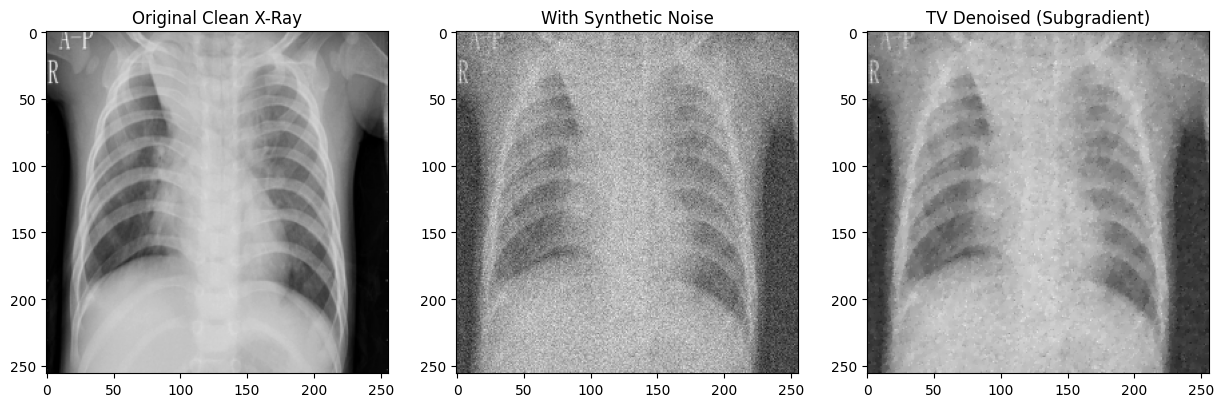

In [15]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. Path Discovery
# Checking common Kaggle/Colab extraction paths
base_candidates = ['/content/chest_xray/', '/content/chest_xray/chest_xray/']
img_dir = None

for base in base_candidates:
    path = os.path.join(base, 'train/PNEUMONIA')
    if os.path.exists(path):
        img_dir = path
        break

if img_dir is None:
    print("Listing /content/ to help debug:")
    !ls -R /content/
    raise FileNotFoundError("Could not find the PNEUMONIA folder. Check the folder list above.")

# Get first valid image
image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
img_path = os.path.join(img_dir, image_files[0])
print(f"Testing on: {img_path}")

# 2. Loading and Pre-processing
original_img = Image.open(img_path).convert('L')
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
img_tensor = transform(original_img).unsqueeze(0)

# 3. Add Synthetic Gaussian Noise
noise = torch.randn(img_tensor.size()) * 0.1
noisy_img = img_tensor + noise

# 4. Initialize Layer (Using the optimized version from Cell 2)
# lambda_tv is now a parameter inside, so we don't pass it in __init__
tv_layer = TVDenoisingLayer(iterations=15)

# 5. Run Denoising (using no_grad to save memory)
with torch.no_grad():
    denoised_img = tv_layer(noisy_img)

# 6. Plotting
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Clean X-Ray")
plt.imshow(img_tensor.squeeze(), cmap='gray')

plt.subplot(1, 3, 2)
plt.title("With Synthetic Noise")
plt.imshow(noisy_img.squeeze(), cmap='gray')

plt.subplot(1, 3, 3)
plt.title("TV Denoised (Subgradient)")
plt.imshow(denoised_img.squeeze(), cmap='gray')
plt.show()

In [16]:
import torchvision.models as models
from torchvision import datasets
class RobustTVClassifier(nn.Module):
    def __init__(self, num_classes=2, iterations=5):
        super(RobustTVClassifier, self).__init__()

        self.tv_denoiser = TVDenoisingLayer(iterations=iterations)
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Ensure the first layer expects exactly 1 channel
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        # 1. Force the input to be 4D: [Batch, 1, 224, 224]
        if x.dim() == 3:
            x = x.unsqueeze(1)

        # 2. Denoise
        denoised_x = self.tv_denoiser(x)

        # 3. Final safety check: ensure denoised_x is [Batch, 1, H, W]
        if denoised_x.shape[1] != 1:
             denoised_x = denoised_x[:, 0:1, :, :]

        logits = self.backbone(denoised_x)
        return logits, denoised_x

In [17]:
from torchvision import datasets
import os

# 1. Define Transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# 2. Identify correct paths (handling potential nested folders)
base_path = '/content/chest_xray/'
if not os.path.exists(os.path.join(base_path, 'train')):
    base_path = '/content/chest_xray/chest_xray/'

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# 3. Create Datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)

# 4. Create Loaders (Reduced batch_size to 16 to save RAM)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Dataset loaded successfully!")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Dataset loaded successfully!
Train batches: 326 | Test batches: 39


In [18]:
# 1. Re-initialize with faster settings
model = RobustTVClassifier(num_classes=2, iterations=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 2. Optimized Training Call
def train_model(model, train_loader, criterion, optimizer, epochs=2): # 2 epochs is enough given your 94% start
    model.train()
    for epoch in range(epochs):
        correct, total = 0, 0
        loop = tqdm(enumerate(train_loader), total=len(train_loader))

        for batch_idx, (inputs, labels) in loop:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            if inputs.shape[1] > 1: inputs = inputs[:, 0:1, :, :]

            optimizer.zero_grad(set_to_none=True) # Faster than zero_grad()
            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                model.tv_denoiser.lambda_tv.clamp_(min=1e-4, max=0.5)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(acc=f"{100.*correct/total:.2f}%", lam=f"{model.tv_denoiser.lambda_tv.item():.3f}")

        gc.collect()
        torch.cuda.empty_cache()

    print("Finished Optimized Training!")

train_model(model, train_loader, criterion, optimizer, epochs=2)

Epoch [2/2]: 100%|██████████| 326/326 [32:01<00:00,  5.89s/it, acc=98.47%, lam=0.047]


Finished Optimized Training!


In [21]:
#robusteness test
import torch
import torch.nn as nn
import torchvision.models as models

# 1. Setup Baseline (Standard Model without TV Layer)
# We recreate it to ensure it's "fresh" and has no denoising advantage
baseline_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
baseline_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False).to(device)
baseline_model.fc = nn.Linear(baseline_model.fc.in_features, 2).to(device)
baseline_model.eval()

# 2. Updated Robustness Evaluation Function (Handles both model types)
def evaluate_robustness(model, test_loader, noise_factor=0.15, is_robust_model=True):
    model.eval()
    correct = 0
    total = 0

    print(f"Testing {'Robust TV' if is_robust_model else 'Standard Baseline'} Model...")

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            if inputs.shape[1] > 1:
                inputs = inputs[:, 0:1, :, :]

            # Add Synthetic Noise to challenge the model
            noisy_inputs = inputs + noise_factor * torch.randn_like(inputs)
            noisy_inputs = torch.clamp(noisy_inputs, 0, 1)

            # --- Handle the different return types ---
            if is_robust_model:
                outputs, _ = model(noisy_inputs) # Robust model returns (logits, denoised_img)
            else:
                outputs = model(noisy_inputs)    # Standard model returns only (logits)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

# 3. Run the Comparison
# Using a noise_factor of 0.15 to really see the difference
noise_lvl = 0.15

baseline_acc = evaluate_robustness(baseline_model, test_loader, noise_factor=noise_lvl, is_robust_model=False)
robust_acc = evaluate_robustness(model, test_loader, noise_factor=noise_lvl, is_robust_model=True)

print("\n" + "="*40)
print(f"RESULTS AT NOISE LEVEL: {noise_lvl}")
print(f"Standard Baseline ResNet: {baseline_acc:.2f}%")
print(f"Your Robust TV-Model:     {robust_acc:.2f}%")
print(f"Improvement in Robustness: {robust_acc - baseline_acc:.2f}%")
print("="*40)

Testing Standard Baseline Model...


100%|██████████| 39/39 [01:06<00:00,  1.70s/it]


Testing Robust TV Model...


100%|██████████| 39/39 [01:07<00:00,  1.74s/it]


RESULTS AT NOISE LEVEL: 0.15
Standard Baseline ResNet: 37.50%
Your Robust TV-Model:     71.47%
Improvement in Robustness: 33.97%


In [22]:
# Save the trained model weights
torch.save(model.state_dict(), 'robust_tv_model_weights.pth')
print("Model saved! Download this file from the Colab file explorer on the left.")

Model saved! Download this file from the Colab file explorer on the left.
